<a href="https://colab.research.google.com/github/SutamaSarkar/RealiabilitySimulation/blob/main/assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import random
import matplotlib.pyplot as plt
import math

In [7]:
lamda=0.005
mission_time=200


p = math.exp(-lamda*mission_time)

R = sum(math.comb(4, i) * (p**i) * ((1-p)**(4-i)) for i in range(2, 5))

print("Analytical Reliability:", R)


Analytical Reliability: 0.4686620691429672



TRIALS(N)	Reliability_200
-----------------------------------------------------------------------
100			0.5000
1000			0.4640
10000			0.4626
100000			0.4660
1000000			0.4680
-----------------------------------------------------------------------


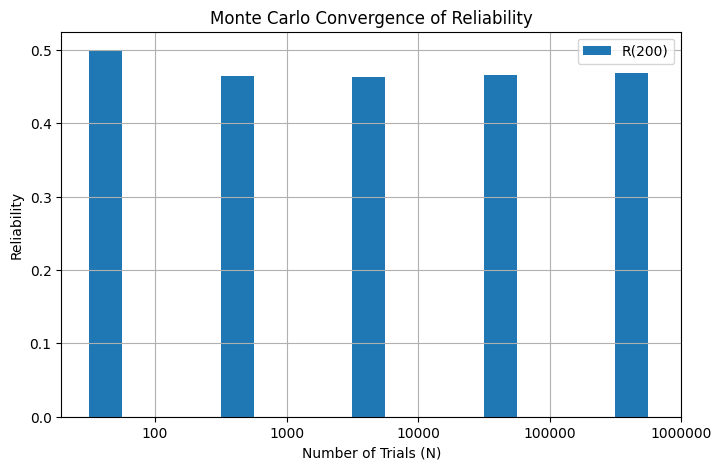

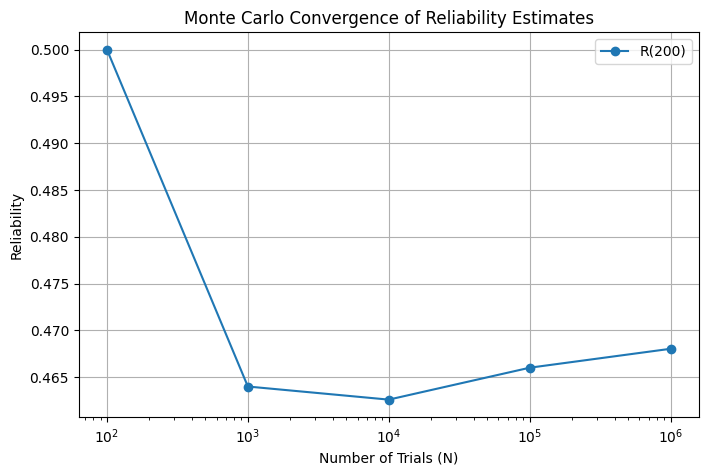

In [8]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

trial_list=[100,1000,10000,100000,1000000]

N_list=[]
Rel_200_list=[]

lamda=0.005

print("\nTRIALS(N)\tReliability_200")
print("-----------------------------------------------------------------------")

for N in trial_list:

    sum_1=0
    sum_2=0
    sum_3=0
    sum_4=0


    for i in range(N):
       Fa=random.uniform(0,1)
       Fb=random.uniform(0,1)
       Fc=random.uniform(0,1)
       Fd=random.uniform(0,1)

       ta=-math.log(1-Fa)/(lamda)
       tb=-math.log(1-Fb)/(lamda)
       tc=-math.log(1-Fc)/(lamda)
       td=-math.log(1-Fd)/(lamda)


       count=sum([ta>=200,tb>=200,tc>=200,td>=200])
       if count>=2:
        sum_1=sum_1+1

    Reliability=sum_1/N



    N_list.append(N)
    Rel_200_list.append(Reliability)
    print(f"{N}\t\t\t{Reliability:.4f}")

print("-----------------------------------------------------------------------")
x=np.arange(len(N_list))
width=0.25

plt.figure(figsize=(8,5))

plt.bar(x - 1.5*width, Rel_200_list, width, label="R(200)")

plt.xticks(x,N_list)

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability")

plt.legend()
plt.grid(True)

plt.show()


# ---------- BAR CHART ----------

plt.figure(figsize=(8,5))

plt.plot(N_list,Rel_200_list,marker='o',label="R(200)")


plt.xscale("log")   # log scale shows convergence clearly

plt.xlabel("Number of Trials (N)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability Estimates")

plt.legend()
plt.grid(True)

plt.show()


True (Analytical) Reliability: 0.468662

TRIALS(N)	Experimental Reliability
------------------------------------------------------
100			0.480000
1000			0.462000
10000			0.465300
100000			0.467730
1000000			0.468447


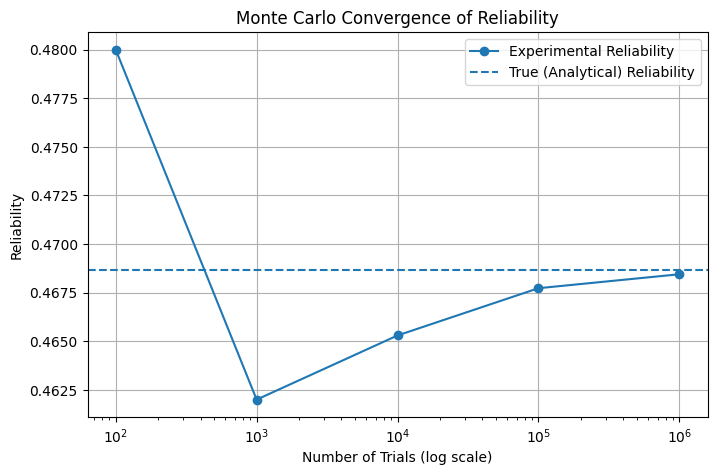

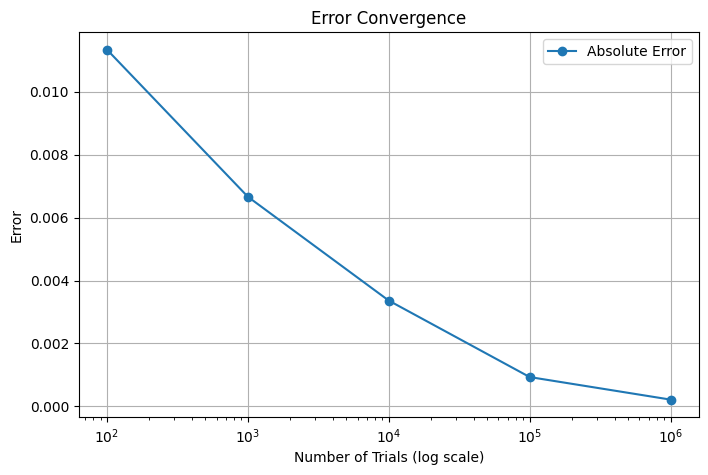

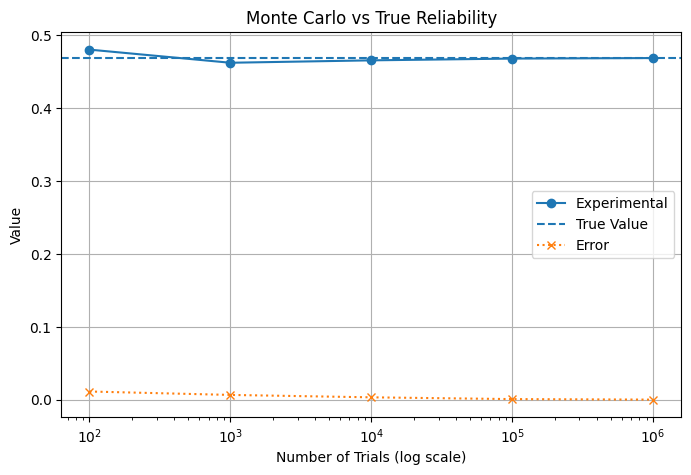

In [13]:
import random
import math
import matplotlib.pyplot as plt
import numpy as np

lamda = 0.005
mission_time = 200

trial_list = [100, 1000, 10000, 100000, 1000000]


p = math.exp(-lamda * mission_time)

R_true = sum(math.comb(4, i) * (p**i) * ((1 - p)**(4 - i)) for i in range(2, 5))

print("\nTrue (Analytical) Reliability:", round(R_true, 6))


N_list = []
Rel_200_list = []

print("\nTRIALS(N)\tExperimental Reliability")
print("------------------------------------------------------")

for N in trial_list:
    system_success = 0

    for i in range(N):

        Fa = random.uniform(0, 1)
        Fb = random.uniform(0, 1)
        Fc = random.uniform(0, 1)
        Fd = random.uniform(0, 1)

        ta = -math.log(1 - Fa) / lamda
        tb = -math.log(1 - Fb) / lamda
        tc = -math.log(1 - Fc) / lamda
        td = -math.log(1 - Fd) / lamda


        working = sum([ta >= 200, tb >= 200, tc >= 200, td >= 200])

        if working >= 2:
            system_success += 1

    Reliability = system_success / N

    N_list.append(N)
    Rel_200_list.append(Reliability)

    print(f"{N}\t\t\t{Reliability:.6f}")


error_list = [abs(r - R_true) for r in Rel_200_list]

# ---------------- PLOT 1: RELIABILITY ----------------
plt.figure(figsize=(8, 5))

plt.plot(N_list, Rel_200_list,
         marker='o',
         label="Experimental Reliability")

plt.axhline(y=R_true,
            linestyle="--",
            label="True (Analytical) Reliability")

plt.xscale("log")

plt.xlabel("Number of Trials (log scale)")
plt.ylabel("Reliability")
plt.title("Monte Carlo Convergence of Reliability")

plt.legend()
plt.grid(True)
plt.show()

# ---------------- PLOT 2: ERROR ----------------
plt.figure(figsize=(8, 5))

plt.plot(N_list, error_list,
         marker='o',
         label="Absolute Error")

plt.xscale("log")

plt.xlabel("Number of Trials (log scale)")
plt.ylabel("Error")
plt.title("Error Convergence")

plt.legend()
plt.grid(True)
plt.show()

# ---------------- PLOT 3: COMBINED ----------------
plt.figure(figsize=(8, 5))

plt.plot(N_list, Rel_200_list,
         marker='o',
         label="Experimental")

plt.axhline(y=R_true,
            linestyle="--",
            label="True Value")

plt.plot(N_list, error_list,
         marker='x',
         linestyle=':',
         label="Error")

plt.xscale("log")

plt.xlabel("Number of Trials (log scale)")
plt.ylabel("Value")
plt.title("Monte Carlo vs True Reliability")

plt.legend()
plt.grid(True)
plt.show()

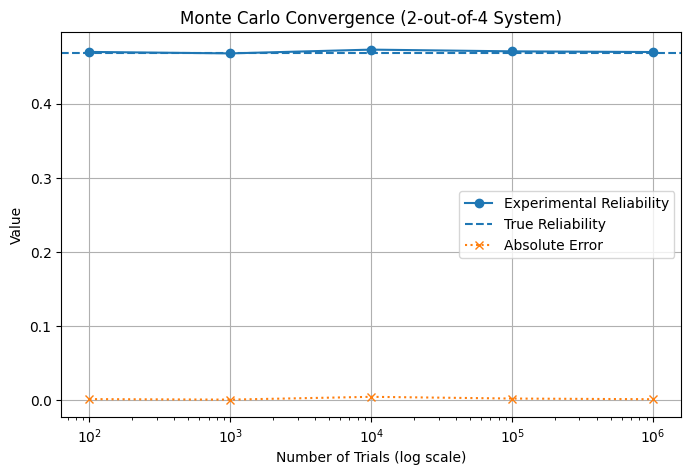

In [12]:
plt.figure(figsize=(8, 5))

# Experimental Reliability
plt.plot(N_list, Rel_200_list,
         marker='o',
         label="Experimental Reliability")

# True (Analytical) Reliability
plt.axhline(y=R_true,
            linestyle="--",
            label="True Reliability")

# Error
plt.plot(N_list, error_list,
         marker='x',
         linestyle=':',
         label="Absolute Error")

plt.xscale("log")

plt.xlabel("Number of Trials (log scale)")
plt.ylabel("Value")
plt.title("Monte Carlo Convergence (2-out-of-4 System)")

plt.legend()
plt.grid(True)

plt.show()